!pip install nats_bench

In [ ]:
import torch
import numpy as np
import random
import os
import tarfile
from nats_bench import create
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

from torch.utils.data import TensorDataset, DataLoader, random_split
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from utils import set_seed, decoded_x_to_nas201_arch,pretrain_and_freeze_vae,build_accuracy_pairs
from dataset_loader import arch_to_tensor,NASDatasetFactory,tensor_to_genotype,genotype_to_tensor
from model import VAE_dist,vae_accuracy_loss,FlowNet,flow_loss
import matplotlib.pyplot as plt

# Datasets Used

In this work, two benchmark datasets are used: **NAS-Bench-201** and **NAS-Bench-301 / DARTS**.

|               | NAS-Bench-201               | NAS-Bench-301 / DARTS                                          |
| ------------- | --------------------------- | -------------------------------------------------------------- |
| Architectures | 15,625                      | ~10¹⁸ possible architectures, sampled through the search space |
| Structure     | 1 cell, 4 nodes             | 2 cells, normal and reduction, with 4 intermediate nodes each  |
| Operations    | 6                           | 8                                                              |
| Encoding      | ((6, 4, 4) = 96) dimensions | ((2, 8, 6, 6) = 504) dimensions                                |
| Accuracy      | Real lookup table           | Surrogate model, based on an ensemble predictor                |


## NAS-bench-201

In [2]:
# ── PATH CONFIG ──────────────────────────────────────────────────────────
# Questo notebook sta in progetto-deeplearning/latent_space/
# I dataset stanno in progetto-deeplearning/datasets/
BASE_DIR     = os.path.dirname(os.path.abspath('__file__'))
DATASETS_DIR = os.path.abspath(os.path.join(BASE_DIR, '../datasets'))

percorso_tar     = os.path.join(DATASETS_DIR, 'NATS-tss-v1_0-3ffb9-simple.tar')
DATASET_PATH     = os.path.join(DATASETS_DIR, 'NATS-tss-v1_0-3ffb9-simple')

# Estrazione archivio (solo la prima volta)
if not os.path.exists(DATASET_PATH):
    print('Estrazione in corso...')
    with tarfile.open(percorso_tar, 'r') as tar:
        tar.extractall(path=DATASETS_DIR)
    print('Estrazione completata!')
else:
    print('Dataset già estratto.')

# Caricamento API NATS-Bench TSS
api = create(DATASET_PATH, 'tss', fast_mode=True, verbose=False)
print(f'Architetture totali: {len(api)}')


Dataset già estratto.
Architetture totali: 15625


In [3]:
#setting seed
set_seed()
DEVICE = "cuda"

an element of the dataset: 
- DAG of the architecture where each node is a cell of operations (conv, max pooling)
- results of different datasets 

In [4]:
api.show(1)

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> 012 epochs >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~1|+|skip_connect~0|nor_conv_3x3~1|skip_connect~2|
datasets : ['cifar10-valid', 'cifar10', 'cifar100', 'ImageNet16-120'], extra-info : None
cifar10-valid  FLOP=113.95 M, Params=0.802 MB, latency=16.85 ms.
cifar10-valid  train : [loss = 0.382 & top1 = 86.97%], valid : [loss = 0.514 & top1 = 82.83%]
cifar10        FLOP=113.95 M, Params=0.802 MB, latency=16.85 ms.
cifar10        train : [loss = 0.243 & top1 = 91.69%], test  : [loss = 0.362 & top1 = 88.22%]
cifar100       FLOP=113.96 M, Params=0.808 MB, latency=15.36 ms.
cifar100       train : [loss = 1.271 & top1 = 63.76%], valid : [loss = 1.495 & top1 = 57.80%], test : [loss = 1.478 & top1 = 58.26%]
ImageNet16-120 FLOP= 28.50 M, Params=0.810 MB, latency=13.77 ms.
ImageNet16-120 train : [loss = 2.548 & top1 = 35.41%], valid : [loss = 2.580 & top1 = 35.43%], test : [loss = 2.611 & top1 = 33.80%]
>>>>>>>>

In [5]:
#architecture string
print(api[0])

|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~1|+|nor_conv_1x1~0|skip_connect~1|skip_connect~2|


to see results of  a specific architecture:

In [6]:
idx = 1

# Accuracy on cifar10
info_cifar10 = api.get_more_info(idx, 'cifar10', is_random=False)
print('cifar10  test-accuracy:', info_cifar10.get('test-accuracy'))

# Accuracy on cifar100
info_cifar100 = api.get_more_info(idx, 'cifar100', is_random=False)
print('cifar100 test-accuracy:', info_cifar100.get('test-accuracy'))


cifar10  test-accuracy: 88.22
cifar100 test-accuracy: 58.25999995727539


functions for converting string into torch tensor and viceversa:

In [7]:
#converting architecture string into torch tensor
T = arch_to_tensor(arch_str=api[0])
#from torch tensor into architecture string
arch_str = decoded_x_to_nas201_arch(T)

print(T,arch_str)

[[[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 1. 1.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 1. 1.]
  [0. 0. 0. 1.]
  [0. 0. 0. 0.]]

 [[0. 1. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]] |avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~1|+|nor_conv_1x1~0|skip_connect~1|skip_connect~2|


In [8]:
all_tensors = []

for i in range(len(api)):
    arch_str = api[i]
    A = arch_to_tensor(arch_str)
    all_tensors.append(A)

X = np.stack(all_tensors)  # shape: (N_architetture, 6, 4, 4)
print('X shape:', X.shape)


X shape: (15625, 6, 4, 4)


In [9]:
X = torch.tensor(X)       # shape: (N_architetture, 6, 4, 4)
X = X.view(len(X), -1)    # flatten → (N_architetture, 96)
print('X shape:', X.shape)


X shape: torch.Size([15625, 96])


### data loading 

The `NASDatasetFactory.create()` method takes as input the name of the benchmark and returns the train and test dataset and loader.

In [10]:
train_dataset,test_dataset,train_laoder,test_loader = NASDatasetFactory.create(
    benchmark_name="NAS201",
    api=api,
    dataset_name="cifar10",
    metric="test-accuracy",
    hp="12",
    flatten=True,
    normalize_y=True
)

In [11]:
print(len(train_dataset), len(test_dataset))

12500 3125


### VAE for NAS201 

Compared to the VAE used for NATS-Bench, whose input representation has 96 dimensions, the DARTS/NAS301 VAE will be deeper in order to handle a substantially larger architectural encoding.

|  | NATS-Bench VAE | 
|---|---|
| Input dimension | 96 | 
| Latent dimension | 16 | 
| Encoder | 96 → 128 → 64 → (μ, logσ²) |
| Decoder | 16 → 128 → 128 → 96 | 
| Output shape | (4, 4, 6) | 

The loss used is **vae_accuracy_loss**:
$$\mathcal{L}_{VAE}
=
\mathcal{L}_{rec}
+
\beta \, \mathcal{L}_{KL}
+
\lambda_{acc} \, \mathcal{L}_{acc}$$
where: 
- $\mathcal{L}_{rec}$ is the reconstruction loss
- $\mathcal{L}_{KL}$ is the KL divergence
- $\mathcal{L}_{acc}$ is the MSE between the predicted accuracy and the ground-truth accuracy provided by the benchmark.



In [12]:
model = VAE_dist().to(DEVICE)
loss_fn = vae_accuracy_loss

#### VAE training 

the `pretrain_and_freeze_vae()` function trains the **VAE** using the function for the loss given in input

In the following section we'll train a VAE with the loss with and without the term using the accuracy and we'll plot the principal components of the resulting latent space.
With $\lambda$ = 0:

In [13]:
model_no_acc = pretrain_and_freeze_vae(
    model_VAE=model,
    pretrain_loader=train_laoder,
    loss_fn=vae_accuracy_loss,
    vae_epochs=200,
    beta=1.3,
    lambda_acc=0,
    DEVICE=DEVICE,
)

VAE pretrain epoch 000 | loss=0.764781 | recon=0.760361 | kl=0.003400 | acc_loss=0.000000
VAE pretrain epoch 050 | loss=0.603820 | recon=0.603727 | kl=0.000072 | acc_loss=0.000000
Early stopping: patience reached at epoch 96, best_loss=0.603610
VAE pretrained and frozen.


In [14]:
model.eval()
X_train = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))]).to(DEVICE)
y_train = torch.stack([train_dataset[i][1] for i in range(len(train_dataset))]).to(DEVICE)

with torch.no_grad():
    mu, logvar = model_no_acc.encode(X_train)
    z = mu  
z = z.cpu().numpy()  

pca = PCA(n_components=2)
z_2d_vae = pca.fit_transform(z)

with $\lambda = 1$

In [15]:
for p in model.parameters(): #unfreeze model
    p.requires_grad = True

model.train()

model_acc = pretrain_and_freeze_vae(
    model_VAE=model,
    pretrain_loader=train_laoder,
    loss_fn=vae_accuracy_loss,
    vae_epochs=50,
    beta=1.3,
    lambda_acc=1.0,
    DEVICE=DEVICE,
    early_stop=False,
    freeze_after=False,
    lr=1e-3
)

VAE pretrain epoch 000 | loss=0.706991 | recon=0.603655 | kl=0.002121 | acc_loss=0.100578
VAE pretrained and frozen.


In [16]:
with torch.no_grad():

    mu, logvar = model_acc.encode(X_train)

    z = mu   # embedding stabile
z = z.cpu().numpy()  # embedding del VAE

pca = PCA(n_components=2)
z_2d_vae_acc = pca.fit_transform(z)

**Plotting Latent Space:**

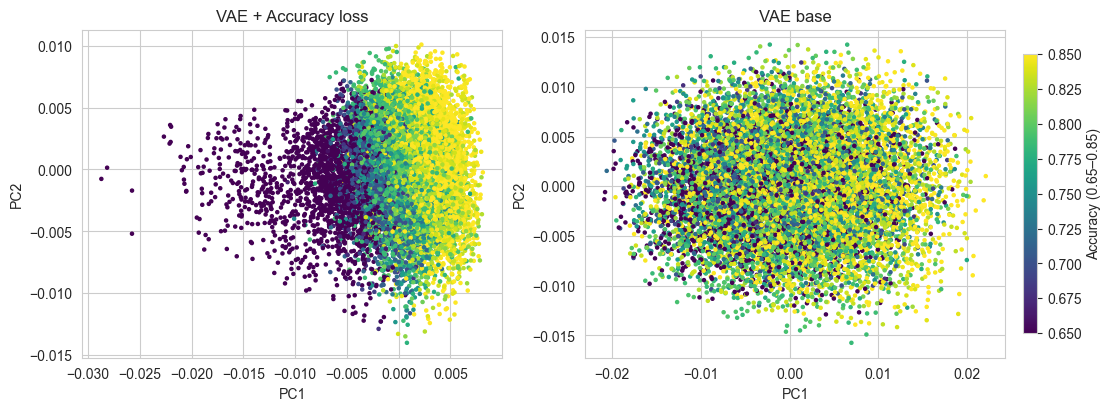

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
y_train = y_train.detach().cpu().numpy()
sc0 = axes[0].scatter(
    z_2d_vae_acc[:,0],
    z_2d_vae_acc[:,1],
    c=y_train,
    cmap="viridis",
    s=5,
    vmin=0.65,
    vmax=0.85
)
axes[0].set_title("VAE + Accuracy loss")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

sc1 = axes[1].scatter(
    z_2d_vae[:,0],
    z_2d_vae[:,1],
    c=y_train,
    cmap="viridis",
    s=5,
    vmin=0.65,
    vmax=0.85
)
axes[1].set_title("VAE base")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
cbar = fig.colorbar(sc1, ax=axes.ravel().tolist(), shrink=0.85, pad=0.02)
cbar.set_label("Accuracy (0.65–0.85)")

plt.show()

### Flow matching 

#### **high accuracy-low accuracy** 

to test Flow Matching:
1. divido le architetture in tre classi in base all'accuracy bassa-media-alta
2. uso flow matching per muovermi nello spazio latente prima da bassa-media e poi da media-alta

In [18]:
y = y_train
idx = np.argsort(y)
n = len(y)
k = n // 2

low_idx  = idx[:k]
high_idx  = idx[k:2*k]

low_mask = np.zeros(n, dtype=bool)
high_mask = np.zeros(n, dtype=bool)

low_mask[low_idx] = True
high_mask[high_idx] = True

In [19]:
#deviding the embeddings into low and high accuracy
z.shape
z_low = z[low_mask]
z_high = z[high_mask]

print(z_low.shape,z_high.shape)

(6250, 16) (6250, 16)


In [20]:
#flow training 
flow1 = FlowNet(dim=16).to(DEVICE)
opt1 = torch.optim.Adam(flow1.parameters(), lr=1e-3)

for epoch in range(200):

    x = torch.tensor(z_low, dtype=torch.float32).to(DEVICE)
    y = torch.tensor(z_high, dtype=torch.float32).to(DEVICE)
    loss = flow_loss(flow1, x, y)

    opt1.zero_grad()
    loss.backward()
    opt1.step()

    if epoch % 20 == 0:
        print("flow1:", loss.item())

flow1: 0.0035856859758496284
flow1: 5.5127744417404756e-05
flow1: 9.077634786081035e-06
flow1: 4.1138123378914315e-06
flow1: 3.827683030976914e-06
flow1: 3.7185056953603635e-06
flow1: 3.656377657534904e-06
flow1: 3.619338258431526e-06
flow1: 3.5806333471555263e-06
flow1: 3.541277010299382e-06


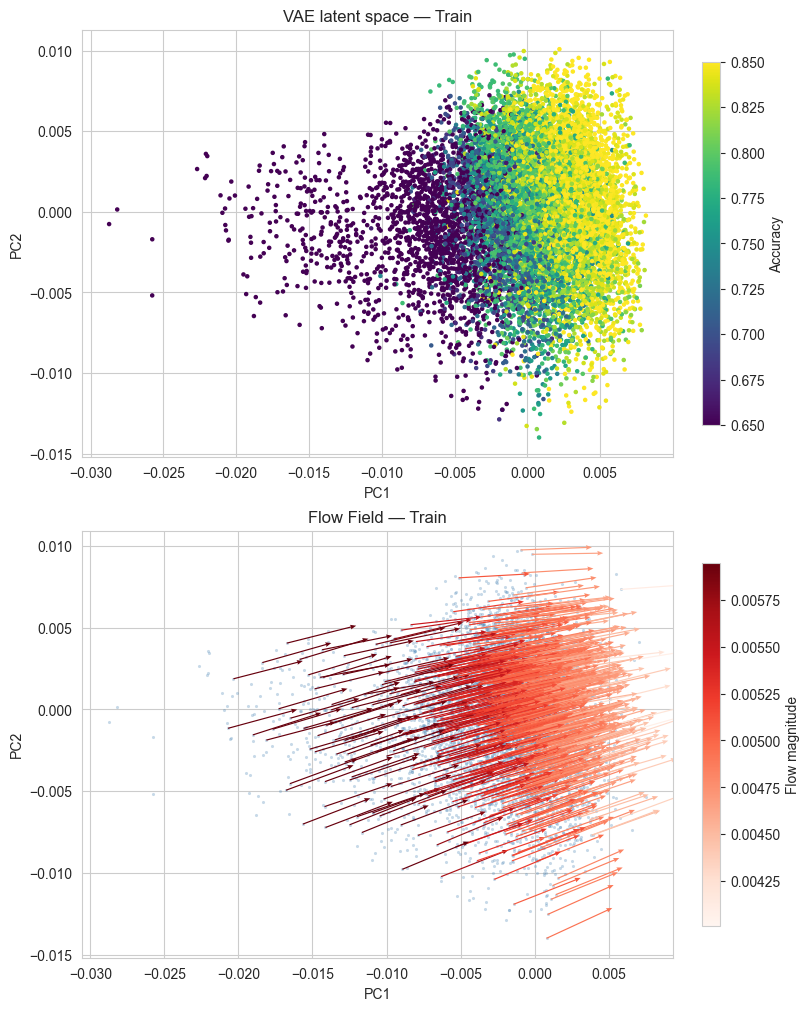

In [21]:
flow1.eval()
model.eval()

X_train = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
X_train = X_train.float().to(DEVICE)

with torch.no_grad():
    mu, logvar = model.encode(X_train)
    z_all = mu

z_all_np = z_all.detach().cpu().numpy()

# y_train per matplotlib
y_train_plot = np.array(y_train)

pca = PCA(n_components=2)
pca.fit(z_all_np)

vae_2d = pca.transform(z_all_np)

#flow field 
z_low_tensor = torch.tensor(z_low, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    v = flow1(z_low_tensor)
z_low_np = z_low_tensor.detach().cpu().numpy()
v_np = v.detach().cpu().numpy()
z_low_2d = pca.transform(z_low_np)
z_next_2d = pca.transform(z_low_np + v_np)
v_2d = z_next_2d - z_low_2d

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 10),
    constrained_layout=True
)

# (0) VAE latent space — train
sc0 = axes[0].scatter(
    vae_2d[:, 0],
    vae_2d[:, 1],
    c=y_train_plot,
    cmap="viridis",
    s=5,
    vmin=0.65,
    vmax=0.85
)

axes[0].set_title("VAE latent space — Train")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

fig.colorbar(
    sc0,
    ax=axes[0],
    shrink=0.85
).set_label("Accuracy")

# (1) Flow field — train
v_mag = np.linalg.norm(v_2d, axis=1)
v_norm = v_2d / (v_mag[:, None] + 1e-8)
arrow_len = np.percentile(v_mag, 30)

idx = np.random.choice(
    len(z_low_2d),
    size=min(800, len(z_low_2d)),
    replace=False
)

axes[1].scatter(
    z_low_2d[:, 0],
    z_low_2d[:, 1],
    color="steelblue",
    s=5,
    alpha=0.3,
    linewidths=0,
    zorder=2
)

q = axes[1].quiver(
    z_low_2d[idx, 0],
    z_low_2d[idx, 1],
    v_norm[idx, 0] * arrow_len,
    v_norm[idx, 1] * arrow_len,
    v_mag[idx],
    cmap="Reds",
    norm=plt.Normalize(
        vmin=v_mag.min(),
        vmax=np.percentile(v_mag, 95)
    ),
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.002,
    headwidth=4,
    headlength=5,
    alpha=1,
    zorder=3
)

axes[1].set_title("Flow Field — Train")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

fig.colorbar(
    q,
    ax=axes[1],
    shrink=0.85
).set_label("Flow magnitude")

plt.show()

### pairwise for continuous learning 

In [22]:
pairs_x, pairs_target = build_accuracy_pairs(
    X=z_all,
    y=y_train,
    K=50,
    min_delta_acc=0.01,
    seed=42
)

random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random
random

In [23]:
import torch.nn as nn
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

flow = FlowNet(dim=16).to(DEVICE)

optimizer = torch.optim.Adam(
    flow.parameters(),
    lr=1e-3
)

pairs_x = pairs_x.to(DEVICE)
pairs_target = pairs_target.to(DEVICE)

epochs = 300

for epoch in range(epochs):

    pred = flow(pairs_x)

    loss = ((pred - pairs_target) ** 2).mean()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch} | Loss {loss.item():.6f}"
        )

Epoch 0 | Loss 0.005179
Epoch 20 | Loss 0.000074
Epoch 40 | Loss 0.000014
Epoch 60 | Loss 0.000002
Epoch 80 | Loss 0.000000
Epoch 100 | Loss 0.000000
Epoch 120 | Loss 0.000000
Epoch 140 | Loss 0.000000
Epoch 160 | Loss 0.000000
Epoch 180 | Loss 0.000000
Epoch 200 | Loss 0.000000
Epoch 220 | Loss 0.000000
Epoch 240 | Loss 0.000000
Epoch 260 | Loss 0.000000
Epoch 280 | Loss 0.000000


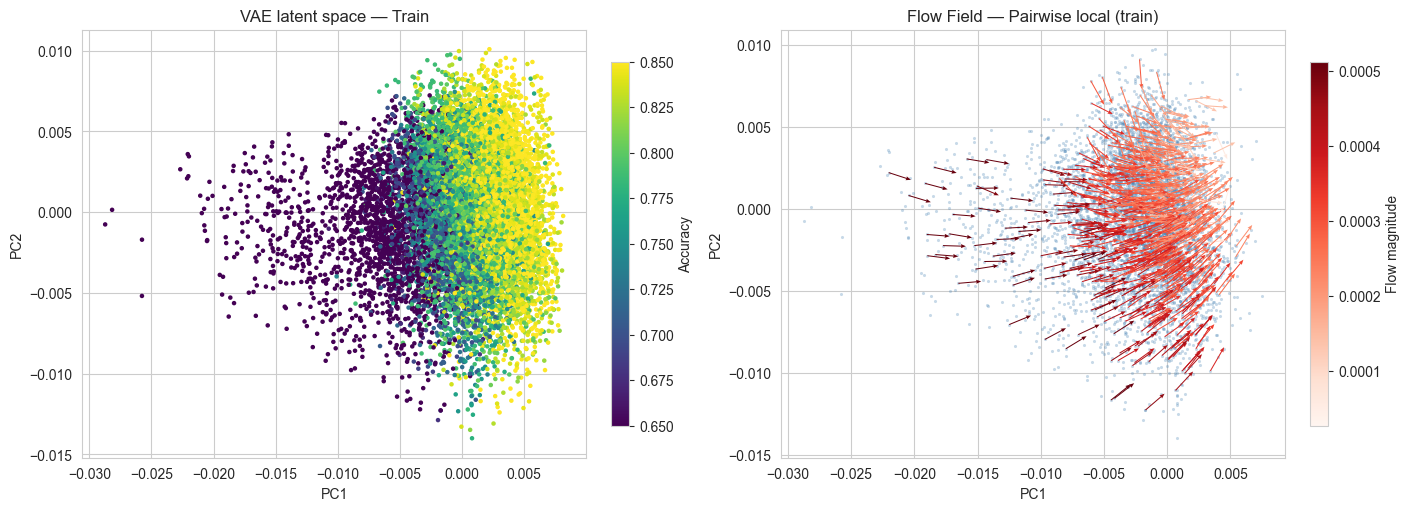

In [24]:
flow.eval()

with torch.no_grad():
    v_new = flow(torch.tensor(z_low, dtype=torch.float32).to(DEVICE))

v_new_np = v_new.cpu().numpy()

z_low_2d_new  = pca.transform(z_low)
z_next_2d_new = pca.transform(z_low + v_new_np)
v_2d_new      = z_next_2d_new - z_low_2d_new

v_mag_new  = np.linalg.norm(v_2d_new, axis=1)
v_norm_new = v_2d_new / (v_mag_new[:, None] + 1e-8)
# Con questa
x_range = z_low_2d_new[:,0].max() - z_low_2d_new[:,0].min()
arrow_len_new = x_range * 0.05  # 5% della larghezza del plot
idx_new = np.random.choice(len(z_low_2d_new), size=min(800, len(z_low_2d_new)), replace=False)

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# (0) VAE latent space
sc0 = axes[0].scatter(
    vae_2d[:,0], vae_2d[:,1],
    c=y_train, cmap="viridis",
    s=5, vmin=0.65, vmax=0.85
)
axes[0].set_title("VAE latent space — Train")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.colorbar(sc0, ax=axes[0], shrink=0.85).set_label("Accuracy")

# (1) Flow field — pairwise local
axes[1].scatter(
    z_low_2d_new[:,0], z_low_2d_new[:,1],
    color="steelblue", s=5, alpha=0.3, linewidths=0, zorder=2
)

q_new = axes[1].quiver(
    z_low_2d_new[idx_new,0], z_low_2d_new[idx_new,1],
    v_norm_new[idx_new,0] * arrow_len_new,
    v_norm_new[idx_new,1] * arrow_len_new,
    v_mag_new[idx_new], cmap="Reds",
    norm=plt.Normalize(vmin=v_mag_new.min(), vmax=np.percentile(v_mag_new, 95)),
    angles="xy", scale_units="xy", scale=1,
    width=0.002, headwidth=4, headlength=5, alpha=1, zorder=3
)
axes[1].set_title("Flow Field — Pairwise local (train)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
fig.colorbar(q_new, ax=axes[1], shrink=0.85).set_label("Flow magnitude")

plt.show()

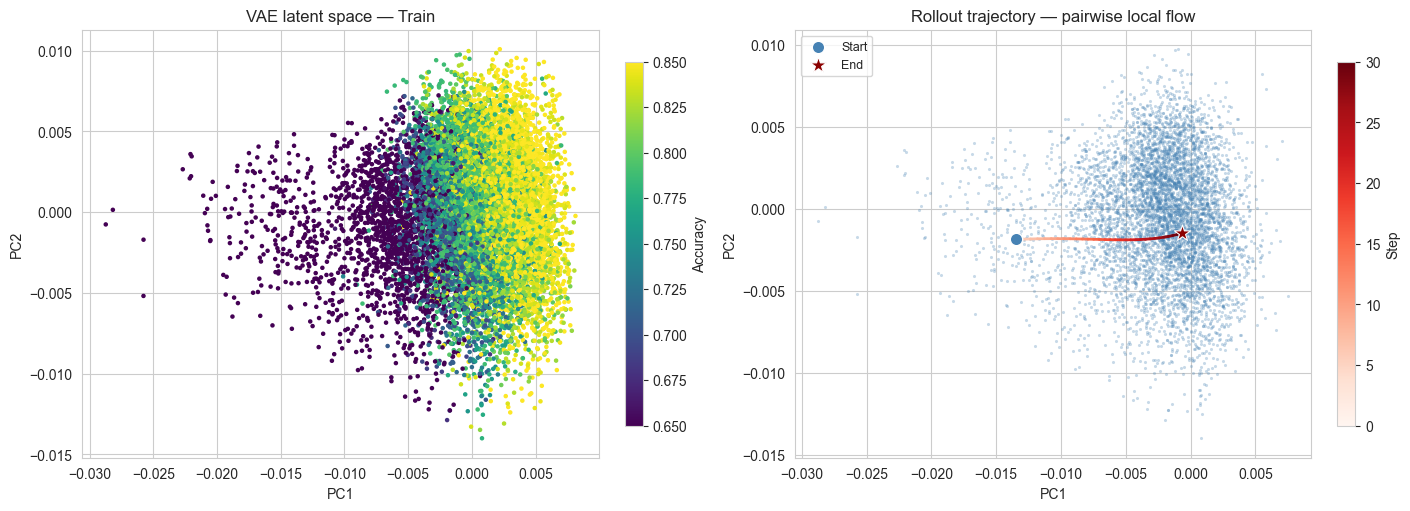

In [26]:
# ============================================================
# ROLLOUT — traiettoria multi-step
# ============================================================
start_idx = np.argmin(y_train)
z_start = z_all_np[start_idx:start_idx+1]

n_steps = 30
step_size = 1
trajectory = [z_start.copy()]

flow.eval()
z_current = z_start.copy()

with torch.no_grad():
    for _ in range(n_steps):
        z_tensor = torch.tensor(z_current, dtype=torch.float32).to(DEVICE)
        v = flow(z_tensor).cpu().numpy()
        z_current = z_current + step_size * v
        trajectory.append(z_current.copy())

trajectory = np.vstack(trajectory)
traj_2d = pca.transform(trajectory)

# ============================================================
# PLOT — stesso stile del flow field
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# (0) VAE latent space
sc0 = axes[0].scatter(
    vae_2d[:,0], vae_2d[:,1],
    c=y_train, cmap="viridis",
    s=5, vmin=0.65, vmax=0.85
)
axes[0].set_title("VAE latent space — Train")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.colorbar(sc0, ax=axes[0], shrink=0.85).set_label("Accuracy")

# (1) Traiettoria
axes[1].scatter(
    z_low_2d_new[:,0], z_low_2d_new[:,1],
    color="steelblue", s=5, alpha=0.3, linewidths=0, zorder=2
)

# Linea colorata per step con cmap="Reds"
n = len(traj_2d)
cmap_traj = plt.cm.Reds
norm_traj = plt.Normalize(0, n_steps)
for i in range(n - 1):
    t = (i + 1) / n_steps
    axes[1].plot(
        traj_2d[i:i+2, 0], traj_2d[i:i+2, 1],
        color=cmap_traj(t * 0.85 + 0.15),  # evita il bianco iniziale
        linewidth=2, solid_capstyle="round", zorder=3
    )

# Start e End
axes[1].scatter(*traj_2d[0],  s=80, color="steelblue",
    zorder=5, edgecolors="white", linewidths=1, label="Start")
axes[1].scatter(*traj_2d[-1], s=150, marker="*", color="darkred",
    zorder=5, edgecolors="white", linewidths=0.8, label="End")

sm = plt.cm.ScalarMappable(cmap=cmap_traj, norm=norm_traj)
sm.set_array([])
fig.colorbar(sm, ax=axes[1], shrink=0.85).set_label("Step")

axes[1].set_title("Rollout trajectory — pairwise local flow")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=9, framealpha=0.8, edgecolor="#ccc")

plt.show()

# NAS301

## dataset laoding

In [29]:
def load_csv_as_dataset(csv_path):
    df = pd.read_csv(csv_path)

    # Prendo tutte le colonne x_0, x_1, ..., x_n
    feature_cols = [col for col in df.columns if col.startswith("x_")]

    # Ordino correttamente: x_0, x_1, ..., x_503
    feature_cols = sorted(
        feature_cols,
        key=lambda c: int(c.split("_")[1])
    )

    X = df[feature_cols].values
    Y = df["accuracy"].values

    X = torch.tensor(X, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)

    dataset = TensorDataset(X, Y)

    print("CSV caricato:", csv_path)
    print("Numero esempi:", len(dataset))
    print("X shape:", X.shape)
    print("Y shape:", Y.shape)
    print("Accuracy min:", Y.min().item())
    print("Accuracy max:", Y.max().item())

    return X, Y, dataset

X, Y, dataset_301 = load_csv_as_dataset(
    "../nas301/nas301_dataset.csv"
)

CSV caricato: ../nas301/nas301_dataset.csv
Numero esempi: 50000
X shape: torch.Size([50000, 504])
Y shape: torch.Size([50000])
Accuracy min: 0.8962019085884094
Accuracy max: 0.9467961192131042



These utility functions are used to move between the DARTS/NAS301 genotype representation and the tensor representation used by the VAE.

- `cell_to_tensor(cell_edges)` converts a single DARTS cell into a one-hot tensor of shape `(N_OPS, TOTAL_NODES, TOTAL_NODES)`. Each active edge is represented by setting to `1` the position corresponding to its operation, source node and destination node.

- `genotype_to_tensor(genotype)` converts a full DARTS genotype into a flattened tensor. Since a NAS301 architecture contains two cells, normal and reduction, the final tensor has shape `(2, 7, 6, 6)`, flattened into a vector of size `504`.

- `tensor_to_cell(x_cell)` performs the inverse operation for a single cell. For each intermediate node, it selects the two best incoming source nodes and the best operation associated with each source. This produces a valid DARTS cell with exactly two incoming edges per intermediate node.

- `tensor_to_genotype(x)` converts a full tensor representation back into a DARTS `Genotype`, reconstructing both the normal and reduction cells.



In [36]:
if isinstance(x, torch.Tensor):
    x = x.detach().cpu().float()

x = torch.tensor(x, dtype=torch.float32)

idx = 0

x_original, y_original = dataset_301[idx]

print("Original x shape:", x_original.shape)
print("Original y:", y_original)

Original x shape: torch.Size([504])
Original y: tensor(0.9334)


C:\Users\tiber\AppData\Local\Temp\ipykernel_13704\2792271084.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)


from tensor to genotype:

In [38]:
genotype = tensor_to_genotype(x_original)

print("GENOTYPE:")
print(genotype)

GENOTYPE:
Genotype(normal=[('dil_conv_3x3', 0), ('skip_connect', 1), ('avg_pool_3x3', 0), ('dil_conv_3x3', 2), ('dil_conv_3x3', 0), ('sep_conv_5x5', 2), ('max_pool_3x3', 0), ('max_pool_3x3', 3)], normal_concat=[2, 3, 4, 5], reduce=[('avg_pool_3x3', 0), ('sep_conv_5x5', 1), ('sep_conv_5x5', 0), ('avg_pool_3x3', 2), ('sep_conv_3x3', 0), ('sep_conv_5x5', 3), ('dil_conv_5x5', 0), ('dil_conv_5x5', 2)], reduce_concat=[2, 3, 4, 5])


c:\Users\tiber\Desktop\em\ALife\Deep-Learning-Project\latent_space\dataset_loader.py:270: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)


from genotype to tensor: 

In [39]:
x_reconstructed = genotype_to_tensor(genotype)

x_reconstructed = torch.tensor(
    x_reconstructed,
    dtype=torch.float32
).view(-1)

print("Reconstructed x shape:", x_reconstructed.shape)

Reconstructed x shape: torch.Size([504])
